# Simulación Avanzada

## Simulación Monte Carlo

Kevin Ferney Hidalgo Higuita
kfhidalgoh@unal.edu.co
Repositorio [GitHub](https://github.com/thepadr30/SimulAva3010192)


### Librerías y configuraciones iniciales

In [269]:
import logging
import os
import sys
import warnings
from time import localtime, strftime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from distfit import distfit
from scipy import stats

from src.graph.fun_graph_matplotlib import FnGraphMat
from src.logs.logger import fn_limpieza_carpeta, setup_logging
from src.utils import lecturaExcel as lE
from src.utils import statisticsBase as sB

In [270]:
__authors__ = ["Kevin Hidalgo"]
__contact__ = "kfhidalgoh@unal.edu.co"
__copyright__ = "Copyright 2026"
__credits__ = ["Kevin Hidalgo"]
__email__ = "kfhidalgoh@unal.edu.co"
__status__ = "Desarrollo"
__version__ = "1.0.0"
__date__ = "2026-02-23"
__file__ = "SimulacionMCIpynb"

file_log = os.path.join('D:\SimulAva\logs', strftime("%Y%m%d%H%M%S", localtime()) + "_" + __file__ + ".log" )

logger = setup_logging(file_log)
logging.info("Python %s on %s", sys.version, sys.platform)
logging.info("Root: %s", os.getcwd())  # os.path.abspath(os.curdir)
logging.info("Log: %s", file_log)

##############
# Constantes #
##############

varData = r'D:\SimulAva\data\raw'
grmt = FnGraphMat('seaborn-v0_8-darkgrid')  # seaborn-v0_8-darkgrid, dark_style
sns.set_palette("husl")
warnings.filterwarnings('ignore')
%matplotlib inline

2026-02-25 08:46:42 [INFO]: Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)] on win32
2026-02-25 08:46:42 [INFO]: Root: D:\SimulAva\notebooks
2026-02-25 08:46:42 [INFO]: Log: D:\SimulAva\logs\20260225084642_SimulacionMCIpynb.log


### Lectura archivo excel

Se realiza la lectura del archivo excel, luego se normaliza sus columnas convirtiendolas a snake_case

In [271]:
dataframes_cargados = lE.leer_multiples_excels(varData)
df_monteCarlo = dataframes_cargados.get(
    "SIMULAVA 2026-02-18 Clase4-2 MONTECARLO EJM (1)", None
)
df_monteCarlo_original = df_monteCarlo.copy()

list_df = [
    df_monteCarlo
]

for i in list_df:
    lE.normalizar_columnas_snake_case(i, inplace=True)

✅ Archivo 'SIMULAVA 2026-02-18 Clase4-2 MONTECARLO EJM (1).xlsx' leído. DataFrame guardado como 'SIMULAVA 2026-02-18 Clase4-2 MONTECARLO EJM (1)'.


Posteriormente, por medio de un ciclo for se selecciona las columnas que son de tipo numérico y se les aplica un reemplazo por la mediana donde haya valores nulos, en nuestro caso el dataframe no posee datos faltantes.

In [272]:
for i in list_df:
    columnas_numericas = i.select_dtypes(include='number').columns
    # reemplazo por cero
    # i[columnas_numericas] = i[columnas_numericas].fillna(0)
    # reemplazo por la mediana
    i[columnas_numericas] = i[columnas_numericas].fillna(i[columnas_numericas].median())

### Análisis exploratorio de datos (EDA)

In [273]:
logging.info('veamos que tienen las columnas')
sB.column_overview(df_monteCarlo)

2026-02-25 08:46:43 [INFO]: veamos que tienen las columnas


,dtype,missing_count,unique_count
datos,int64,0,60
horas,float64,0,60


In [274]:
sB.numeric_descriptive_stats(df_monteCarlo)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,median,missing
datos,60.0,30.500000,17.464249,1.00,1.5900,3.95,6.900,15.7500,30.500,45.25,54.10,57.0500,59.4100,60.00,30.500,0
horas,60.0,19.703667,11.948549,4.03,4.8206,5.63,6.453,14.2875,18.055,22.60,33.59,40.6475,65.1297,65.23,18.055,0


Nuestro interés se concentra en la variable _horas_, tener presente que son unidades de tiempo
* mean 19.70
* median 18.05
* mean y median son cercanas
* std 11.94
* min 4.03, max 65.23

In [275]:
logging.info('EDA')
df_stats = sB.fn_statistics_base(df_monteCarlo, 'horas')
# print(df_stats.T)
df_stats

2026-02-25 08:46:44 [INFO]: EDA


,n_total,n_obs,missing_count,mean,median,var,std,sem,min,max,range,CV_pct,q1,q3,iqr,skewness,kurtosis,ci_mean_lower,ci_mean_upper
0,60,60,0,19.7037,18.055,142.7678,11.9485,1.5426,4.03,65.23,61.2,60.6412,14.2875,22.6,8.3125,1.9875,5.1663,16.617,22.7903


In [276]:
logging.info('Outlier')
dict_out = sB.detectar_outliers(
    df_monteCarlo,
    variable_target='horas'
)

2026-02-25 08:46:45 [INFO]: Outlier



=== DETECCIÓN DE OUTLIERS (MÉTODO IQR) ===

--- horas ---
Límites IQR: [1.82, 35.07]
Outliers detectados: 4 (6.67%)
Valores outliers: [65.06 40.39 45.54 65.23]


### Histograma

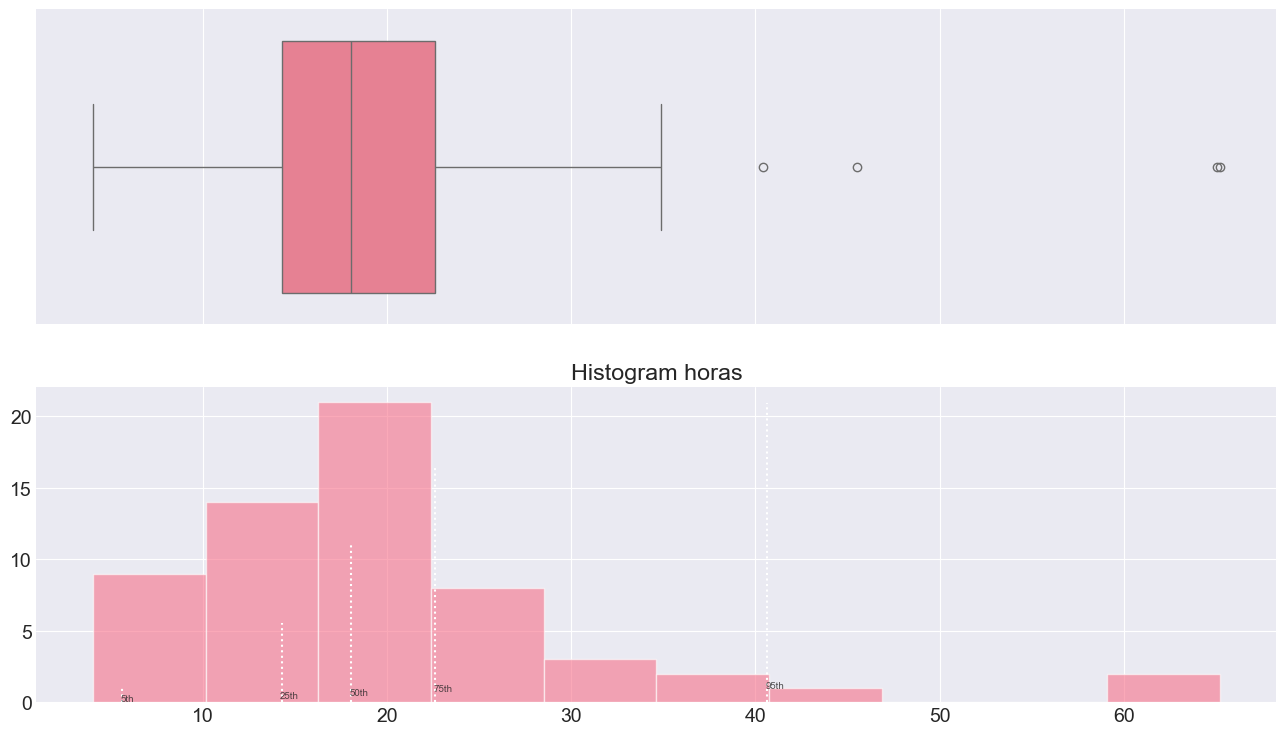

In [277]:
grmt.graph_armor_hist(df_monteCarlo, 'horas')

Cola pesada a derecha, evidencia de datos atípicos, gráficamente no se puede concluir normalidad, se debe pensar en distribuciones diferentes a la normal, una tabla de frecuencias no es útil en este caso, en celdas anteriores vemos que tenemos 60 datos únicos, para que esta tenga sentido debemos crear una variable categórica que agrupe las horas, tenemos una idea intuitiva gracias al histograma en el cual el cálculo del número de barras da aproximadamente 8, este se basa generalmente en la regla de Sturges: $K = 1 + 3.322log_{10}\left( N \right)$

Dado que desconocemos la distribución de los datos y gráficamente dista de la distribución normal, aplicaremos una serie de pruebas para determinar una distribución aproximada de estos

In [278]:
dfit = distfit()
dfit.fit_transform(df_monteCarlo['horas'])
print("La mejor distribución encontrada es:", dfit.model['name'])
print("Parámetros óptimos:", dfit.model['params'])

[25-02-2026 08:46:45] [distfit.distfit] [INFO] fit
[25-02-2026 08:46:45] [distfit.distfit] [INFO] transform
[25-02-2026 08:46:45] [distfit.distfit] [INFO] [norm      ] [0.00 sec] [RSS: 0.00269416] [loc=19.704 scale=11.849]
[25-02-2026 08:46:45] [distfit.distfit] [INFO] [expon     ] [0.00 sec] [RSS: 0.0037582] [loc=4.030 scale=15.674]
[25-02-2026 08:46:45] [distfit.distfit] [INFO] [pareto    ] [0.00 sec] [RSS: 0.0037582] [loc=-2147483643.970 scale=2147483648.000]
[25-02-2026 08:46:46] [distfit.distfit] [INFO] [dweibull  ] [0.01 sec] [RSS: 0.00292146] [loc=18.240 scale=8.079]
[25-02-2026 08:46:46] [distfit.distfit] [INFO] [t         ] [0.06 sec] [RSS: 0.000874127] [loc=17.419 scale=5.377]
[25-02-2026 08:46:46] [distfit.distfit] [INFO] [genextreme] [0.06 sec] [RSS: 0.00198474] [loc=14.437 scale=7.678]
[25-02-2026 08:46:46] [distfit.distfit] [INFO] [gamma     ] [0.01 sec] [RSS: 0.00220683] [loc=2.758 scale=7.545]
[25-02-2026 08:46:46] [distfit.distfit] [INFO] [lognorm   ] [0.00 sec] [RSS: 

La mejor distribución encontrada es: t
Parámetros óptimos: (np.float64(1.8524669032273189), np.float64(17.419045313234577), np.float64(5.3765839723718045))


[25-02-2026 08:46:46] [distfit.distfit] [INFO] Create pdf plot for the parametric method.
[25-02-2026 08:46:46] [distfit.distfit] [INFO] Estimated distribution: T(loc:17.419045, scale:5.376584)


(<Figure size 2000x1500 with 1 Axes>,
 <Axes: title={'center': '\nt(df=1.85247, loc=17.419, scale=5.37658)'}, xlabel='Density values', ylabel='Frequency'>)

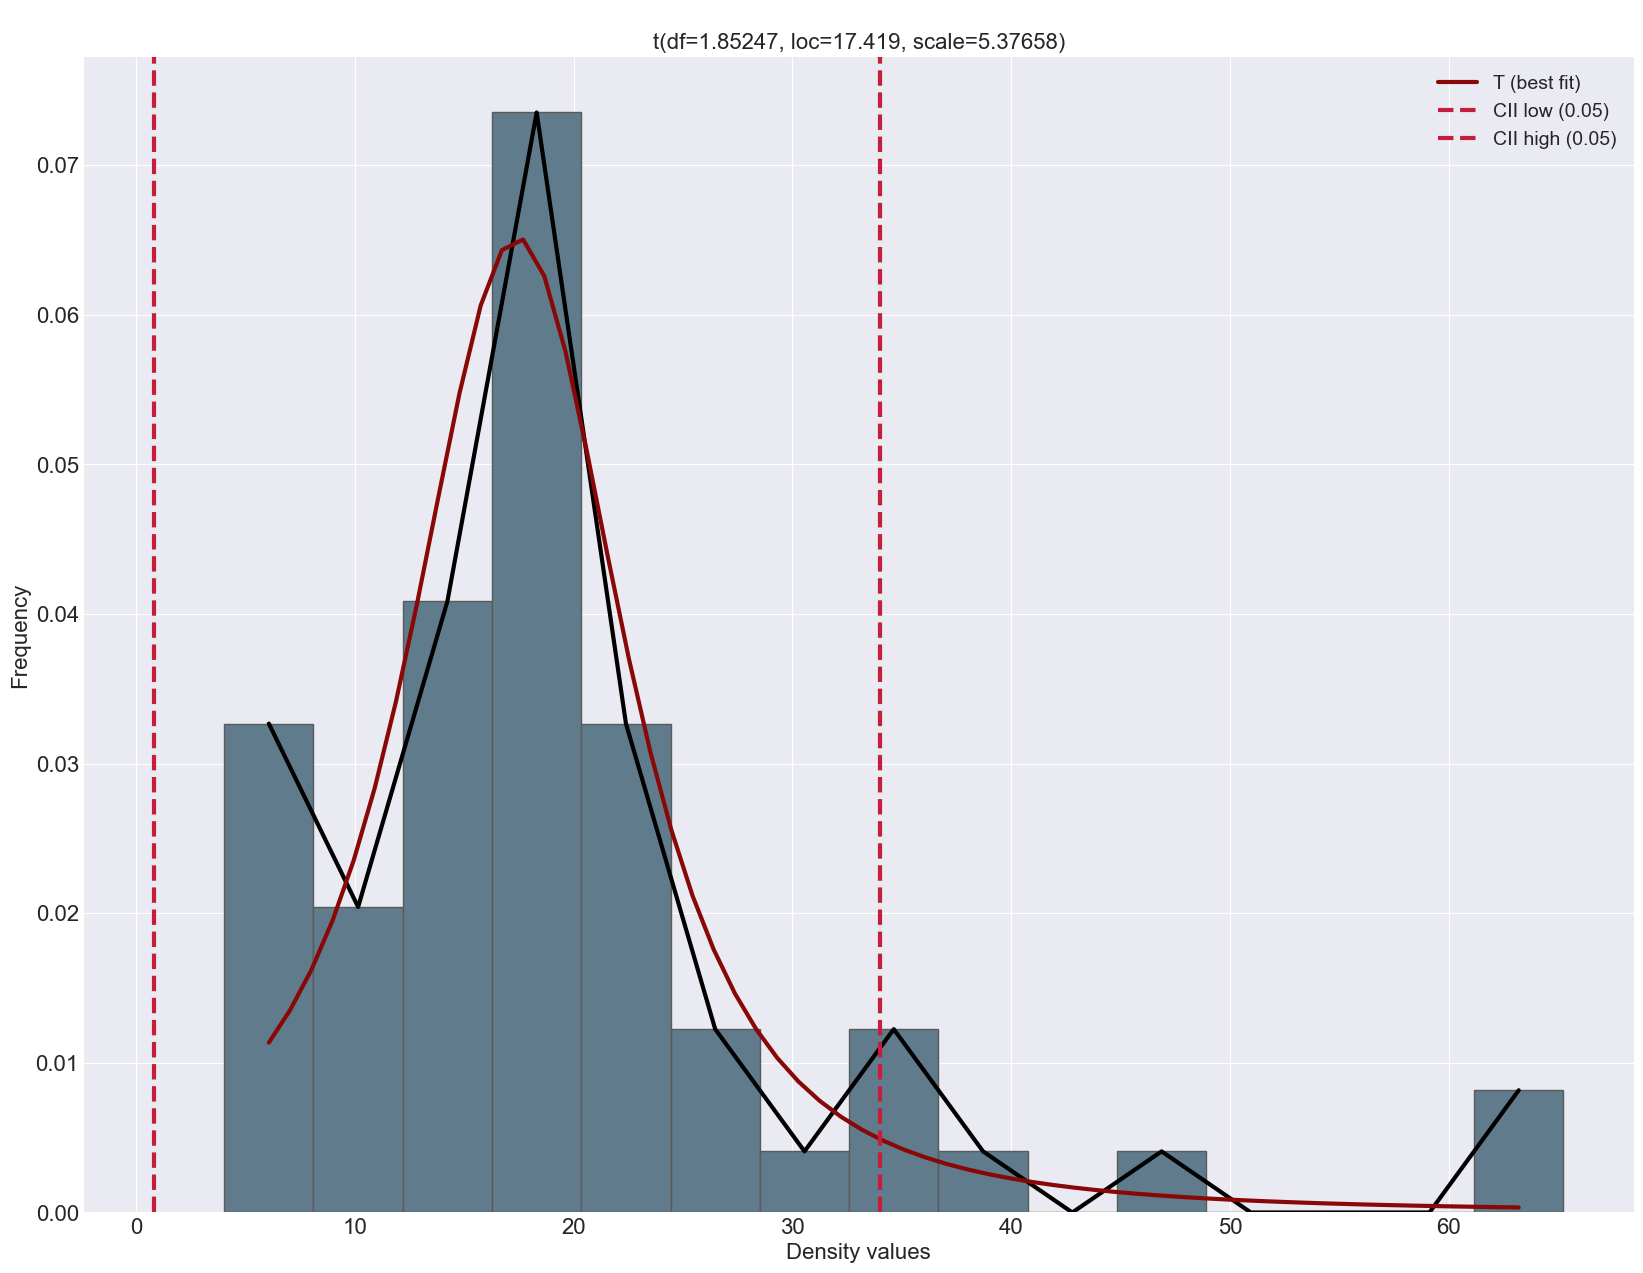

In [279]:
dfit.plot()

Esto nos da que la mejor distribución para nuestros datos es una distribución $X\sim t_{1.85,17.42,5.37}$

Dado que:

* $gl \approx 1.85 \to $ *colas extremadamente pesadas*
* Esto implica:
    * Alta probabilidad de valores extremos.
    * Varianza potencialmente muy grande.


### Configuración de la simulación

In [280]:
# ==============================================================
# CONFIGURACIÓN DE LA SIMULACIÓN
# ==============================================================
DIST_PARAMS = {
    'df': dfit.model['params'][0],  # grados de libertad 1.8524669032273189,
    'loc': dfit.model['params'][1],  # parámetro de ubicación (media) 17.419045313234577,
    'scale': dfit.model['params'][2],  # parámetro de escala (desviación estándar) 5.3765839723718045
}
N_SIMULACIONES = 10000  # Número de iteraciones de Monte Carlo
RANDOM_SEED = 42        # Semilla para reproducibilidad
ALPHA = 0.05            # Nivel de significancia para IC del 95%

Fijamos semilla para que el experimento sea 100% reproducible

In [281]:
np.random.seed(RANDOM_SEED)
print(f"--- Iniciando Simulación de Monte Carlo con {N_SIMULACIONES} iteraciones ---")
# Generación de Muestras Aleatorias (Monte Carlo)
# scipy.stats.t.rvs (Random Variates) genera los datos simulados
horas_simuladas = stats.t.rvs(
    df=DIST_PARAMS['df'],
    loc=DIST_PARAMS['loc'],
    scale=DIST_PARAMS['scale'],
    size=N_SIMULACIONES
)

--- Iniciando Simulación de Monte Carlo con 10000 iteraciones ---


In [282]:
print(f"✅ Simulación completada: {N_SIMULACIONES:,} muestras generadas")
print(f"   Distribución: t(gl={DIST_PARAMS['df']:.2f}, "
      f"loc={DIST_PARAMS['loc']:.2f}, scale={DIST_PARAMS['scale']:.2f})")

✅ Simulación completada: 10,000 muestras generadas
   Distribución: t(gl=1.85, loc=17.42, scale=5.38)


In [283]:
def calcular_estadisticas(datos, nombre="Datos", impresion=False):
    """
    Calcula estadísticas descriptivas clave para un conjunto de datos.

    Args:
        datos (array-like): Datos a analizar
        nombre (str): Nombre para identificar en la salida

    Returns:
        dict: Diccionario con las estadísticas
    """
    stats_dict = {
        'nombre': nombre,
        'n': len(datos),
        'media': np.mean(datos),
        'std': np.std(datos, ddof=1),
        'min': np.min(datos),
        'max': np.max(datos),
        'p1': np.percentile(datos, 1),
        'p5': np.percentile(datos, 5),
        'p25': np.percentile(datos, 25),
        'p50': np.median(datos),
        'p75': np.percentile(datos, 75),
        'p95': np.percentile(datos, 95),
        'p99': np.percentile(datos, 99),
        'iqr': np.percentile(datos, 75) - np.percentile(datos, 25),
        'sesgo': stats.skew(datos),
        'curtosis': stats.kurtosis(datos)
    }

    # Cálculo de Estadísticas Descriptivas
    percentiles = np.percentile(datos, [5, 25, 50, 75, 90, 95, 99])

    if impresion:
        print("\n[Estadísticas Descriptivas]")
        print(f"Media Simulada:       {np.mean(datos):.2f} horas")
        print(f"Mediana Simulada:     {np.median(datos):.2f} horas")
        print(f"Desviación Estándar:  {np.std(datos):.2f} horas")
        print(f"Percentil 25% (Q1):   {percentiles[1]:.2f} horas")
        print(f"Percentil 50% (Q2):   {percentiles[2]:.2f} horas")
        print(f"Percentil 75% (Q3):   {percentiles[3]:.2f} horas")
        print(f"Percentil 95%:        {percentiles[5]:.2f} horas")
    return stats_dict

In [284]:
# Cargar datos
horas_empiricas = df_monteCarlo['horas']

In [285]:
# Calcular estadísticas para datos empíricos y simulados
print("\n Datos Empíricos")
stats_empiricas = calcular_estadisticas(horas_empiricas, "Datos Empíricos")
print("\n Simulación Monte Carlo")
stats_simuladas = calcular_estadisticas(horas_simuladas, "Simulación Monte Carlo")


 Datos Empíricos

 Simulación Monte Carlo


In [286]:
df_comparacion = pd.DataFrame([stats_empiricas, stats_simuladas]).T
df_comparacion.columns = ['Empírico', 'Simulado']
df_comparacion = df_comparacion.drop('nombre')

print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS COMPARATIVAS")
print("="*60)
print(df_comparacion.round(3).to_string())


ESTADÍSTICAS DESCRIPTIVAS COMPARATIVAS
           Empírico     Simulado
n                60        10000
media     19.703667    17.566883
std       11.948549    19.909684
min            4.03  -376.499819
max           65.23  1000.508326
p1           4.8206   -22.591097
p5             5.63     0.973732
p25         14.2875    13.043914
p50          18.055    17.422492
p75            22.6    21.889851
p95         40.6475    33.817728
p99         65.1297    59.547887
iqr          8.3125     8.845937
sesgo       1.98748    12.610296
curtosis   5.166318   677.233571


In [287]:
def bootstrap_ci_media(datos, n_bootstrap=1000, ci=0.95):
    """
    Calcula intervalo de confianza bootstrap para la media.

    Args:
        datos (array): Datos originales
        n_bootstrap (int): Número de remuestreos
        ci (float): Nivel de confianza

    Returns:
        tuple: (límite inferior, límite superior)
    """
    medias_bootstrap = []
    n = len(datos)

    for _ in range(n_bootstrap):
        muestra = np.random.choice(datos, size=n, replace=True)
        medias_bootstrap.append(np.mean(muestra))

    alpha = 1 - ci
    limite_inferior = np.percentile(medias_bootstrap, 100 * alpha / 2)
    limite_superior = np.percentile(medias_bootstrap, 100 * (1 - alpha / 2))

    return limite_inferior, limite_superior

Calcular IC para ambas muestras

In [288]:
ic_empirico = bootstrap_ci_media(horas_empiricas)
ic_simulado = bootstrap_ci_media(horas_simuladas)
print("\n" + "=" * 60)
print("INTERVALOS DE CONFIANZA (95%) PARA LA MEDIA")
print("=" * 60)
print(f"Datos Empíricos:    ({ic_empirico[0]:.2f}, {ic_empirico[1]:.2f})")
print(f"Simulación MC:      ({ic_simulado[0]:.2f}, {ic_simulado[1]:.2f})")


INTERVALOS DE CONFIANZA (95%) PARA LA MEDIA
Datos Empíricos:    (16.82, 22.84)
Simulación MC:      (17.21, 17.98)


In [289]:
def probabilidad_exceder_umbral(datos, umbral):
    """
    Calcula la probabilidad de que los datos superen un umbral dado.

    Args:
        datos (array): Datos a analizar
        umbral (float): Valor umbral

    Returns:
        float: Probabilidad (entre 0 y 1)
    """
    return np.mean(datos > umbral)

Definir umbrales de interés

In [290]:
umbrales = [10, 20, 30, 40, 50, 60]

print("\n" + "=" * 60)
print("PROBABILIDAD DE EXCEDER UMBRALES")
print("=" * 60)
print(f"{'Umbral':>10} | {'P(X > umbral) - Empírico':>25} | {'P(X > umbral) - Simulado':>25}")
print("-" * 70)

for umbral in umbrales:
    prob_emp = probabilidad_exceder_umbral(horas_empiricas, umbral)
    prob_sim = probabilidad_exceder_umbral(horas_simuladas, umbral)
    print(f"{umbral:10.0f} | {prob_emp:25.3f} | {prob_sim:25.3f}")


PROBABILIDAD DE EXCEDER UMBRALES
    Umbral |  P(X > umbral) - Empírico |  P(X > umbral) - Simulado
----------------------------------------------------------------------
        10 |                     0.850 |                     0.846
        20 |                     0.350 |                     0.341
        30 |                     0.117 |                     0.076
        40 |                     0.067 |                     0.029
        50 |                     0.033 |                     0.015
        60 |                     0.033 |                     0.010


In [291]:
prob_mayor_30 = np.mean(horas_simuladas > 30) * 100
prob_menor_10 = np.mean(horas_simuladas < 10) * 100

print("\n[Interpretación de Probabilidades]")
print(f"Probabilidad de que el tiempo supere las 30 horas: {prob_mayor_30:.2f}%")
print(f"Probabilidad de que el tiempo sea menor a 10 horas: {prob_menor_10:.2f}%")


[Interpretación de Probabilidades]
Probabilidad de que el tiempo supere las 30 horas: 7.56%
Probabilidad de que el tiempo sea menor a 10 horas: 15.45%


### Generación de Visualizaciones

In [292]:
print("\n" + "="*60)
print("GENERANDO VISUALIZACIONES")
print("="*60)
# Generación de Visualizaciones
# Calculamos los percentiles 1% y 99% para enfocar los gráficos en la masa principal
# y evitar que las colas pesadas de la t-Student (df=1.85) arruinen la visualización
p1, p99 = np.percentile(horas_simuladas, [1, 99])
rango_x = np.linspace(p1, p99, 1000)
pdf_teorica = stats.t.pdf(rango_x, **DIST_PARAMS)


GENERANDO VISUALIZACIONES


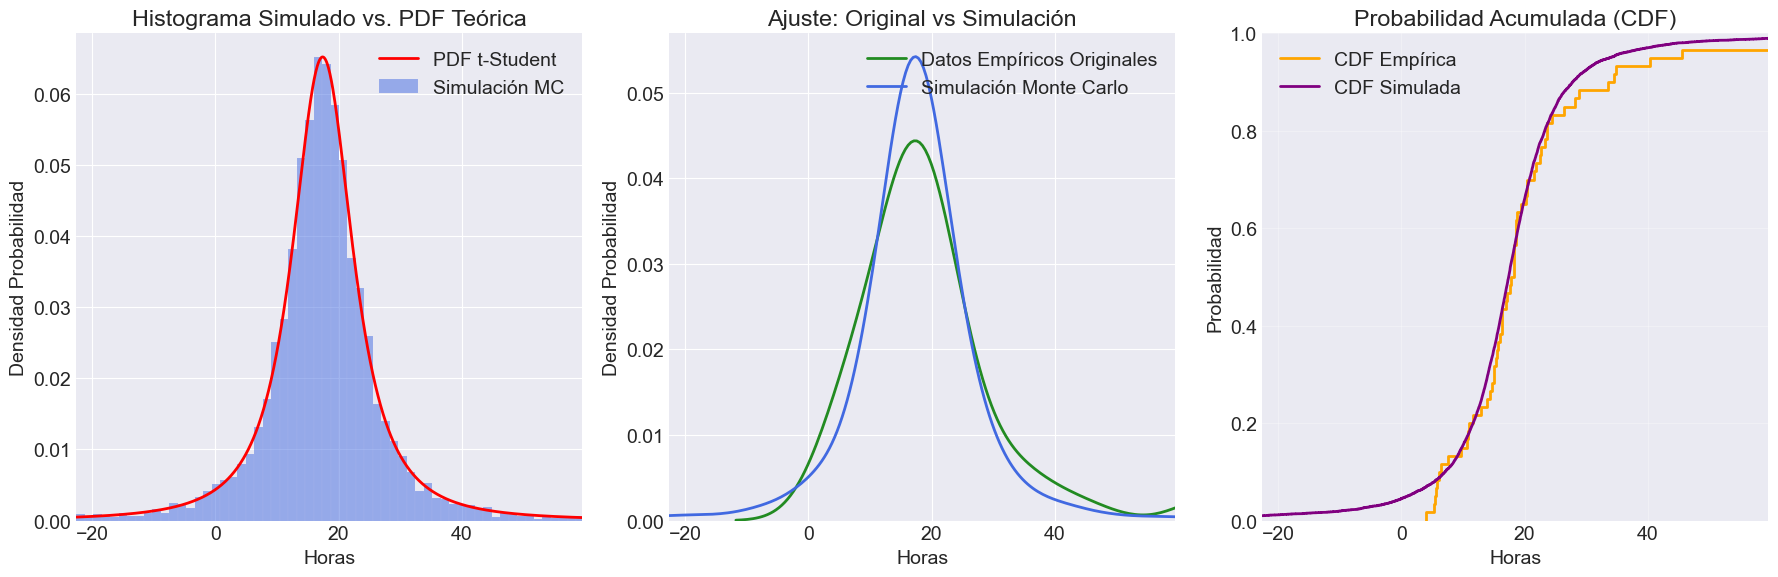

<Figure size 1600x900 with 0 Axes>

In [293]:
_, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico A: Histograma y PDF Teórica
sns.histplot(horas_simuladas, bins=1000, stat='density', alpha=0.5, color='royalblue',
             label='Simulación MC', ax=axes[0])
axes[0].plot(rango_x, pdf_teorica, 'r-', lw=2, label='PDF t-Student')
axes[0].set_xlim(p1, p99)
axes[0].set_title('Histograma Simulado vs. PDF Teórica')
axes[0].set_xlabel('Horas')
axes[0].set_ylabel('Densidad Probabilidad')
axes[0].legend()

# Gráfico B: Comparación Empírica vs Simulada
sns.kdeplot(horas_empiricas, color='forestgreen', lw=2, label='Datos Empíricos Originales',
            ax=axes[1])
sns.kdeplot(horas_simuladas, color='royalblue', lw=2, label='Simulación Monte Carlo',
            ax=axes[1], clip=(p1, p99))
axes[1].set_xlim(p1, p99)
axes[1].set_title('Ajuste: Original vs Simulación')
axes[1].set_xlabel('Horas')
axes[1].set_ylabel('Densidad Probabilidad')
axes[1].legend()

# Gráfico C: Distribución Acumulada (CDF)
sns.ecdfplot(horas_empiricas, color='orange', lw=2, ax=axes[2], label='CDF Empírica')
sns.ecdfplot(horas_simuladas, color='purple', lw=2, ax=axes[2], label='CDF Simulada')
axes[2].set_xlim(p1, p99)
axes[2].set_title('Probabilidad Acumulada (CDF)')
axes[2].set_xlabel('Horas')
axes[2].set_ylabel('Probabilidad')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()
plt.savefig('montecarlo_resultados.png')

### Interpretación de Resultados

In [294]:
print("\n" + "="*60)
print("INTERPRETACIÓN DE RESULTADOS")
print("="*60)

# Comparación de medias
print("\n📊 Comparación de Medias:")
print(f"   - Media Empírica: {stats_empiricas['media']:.2f} horas")
print(f"   - Media Simulada: {stats_simuladas['media']:.2f} horas")
print(f"   - Diferencia: {abs(stats_empiricas['media'] - stats_simuladas['media']):.2f} horas")


INTERPRETACIÓN DE RESULTADOS

📊 Comparación de Medias:
   - Media Empírica: 19.70 horas
   - Media Simulada: 17.57 horas
   - Diferencia: 2.14 horas


In [295]:
if stats_empiricas['curtosis'] > 0:
    print("\n📈 Análisis de Colas:")
    print(f"   - La curtosis positiva ({stats_empiricas['curtosis']:.2f}) indica colas más pesadas que la normal")
    print(f"   - Esto confirma que la distribución t con pocos gl ({DIST_PARAMS['df']:.2f}) es apropiada")
    print("   - Hay mayor probabilidad de valores extremos (tanto muy bajos como muy altos)")


📈 Análisis de Colas:
   - La curtosis positiva (5.17) indica colas más pesadas que la normal
   - Esto confirma que la distribución t con pocos gl (1.85) es apropiada
   - Hay mayor probabilidad de valores extremos (tanto muy bajos como muy altos)


In [296]:
print("\n🎯 Umbrales Críticos:")
for umbral in [30, 40, 50]:
    prob_emp = probabilidad_exceder_umbral(horas_empiricas, umbral)
    prob_sim = probabilidad_exceder_umbral(horas_simuladas, umbral)
    if prob_emp > 0.1:
        print(f"   - Hay una probabilidad del {prob_emp*100:.1f}% (empírico) / {prob_sim*100:.1f}% (simulado) de superar {umbral} horas")


🎯 Umbrales Críticos:
   - Hay una probabilidad del 11.7% (empírico) / 7.6% (simulado) de superar 30 horas


In [297]:
# Rango esperado (percentiles 5-95)
print("\n📏 Rango Esperado (90% de los casos):")
print(f"   - Empírico: entre {stats_empiricas['p5']:.1f} y {stats_empiricas['p95']:.1f} horas")
print(f"   - Simulado: entre {stats_simuladas['p5']:.1f} y {stats_simuladas['p95']:.1f} horas")


📏 Rango Esperado (90% de los casos):
   - Empírico: entre 5.6 y 40.6 horas
   - Simulado: entre 1.0 y 33.8 horas


In [298]:
print("\n✅ CONCLUSIÓN:")
print("   La simulación de Monte Carlo utilizando la distribución t de Student")
print(f"   con parámetros (gl={DIST_PARAMS['df']:.2f}, loc={DIST_PARAMS['loc']:.2f}, "
      f"scale={DIST_PARAMS['scale']:.2f})")
print("   reproduce adecuadamente las características de los datos empíricos.")
print("   Las pequeñas diferencias se deben a la naturaleza estocástica de la")
print(f"   simulación y al tamaño limitado de la muestra original (n={len(horas_empiricas)}).")
print("   Para fines prácticos, podemos usar la distribución simulada para")
print("   realizar inferencias y cálculos de probabilidad sobre la variable HORAS.")


✅ CONCLUSIÓN:
   La simulación de Monte Carlo utilizando la distribución t de Student
   con parámetros (gl=1.85, loc=17.42, scale=5.38)
   reproduce adecuadamente las características de los datos empíricos.
   Las pequeñas diferencias se deben a la naturaleza estocástica de la
   simulación y al tamaño limitado de la muestra original (n=60).
   Para fines prácticos, podemos usar la distribución simulada para
   realizar inferencias y cálculos de probabilidad sobre la variable HORAS.


### Validación adicional: Test de KOLMOGOROV-SMIRNOV

In [299]:
ks_statistic, p_value = stats.ks_2samp(horas_empiricas, horas_simuladas)

print("\n" + "="*60)
print("VALIDACIÓN ESTADÍSTICA: TEST KOLMOGOROV-SMIRNOV")
print("="*60)
print(f"Estadístico KS: {ks_statistic:.4f}")
print(f"Valor p: {p_value:.4f}")

if p_value > 0.05:
    print("✅ No hay evidencia significativa para rechazar que las distribuciones son iguales (p > 0.05)")
    print("   La simulación es estadísticamente consistente con los datos empíricos.")
else:
    print("⚠️  Hay diferencias significativas entre las distribuciones (p < 0.05)")
    print("   Esto puede deberse al tamaño muestral pequeño o a limitaciones del ajuste.")

print("\n" + "="*60)
print("🎉 SIMULACIÓN COMPLETADA EXITOSAMENTE")
print("="*60)


VALIDACIÓN ESTADÍSTICA: TEST KOLMOGOROV-SMIRNOV
Estadístico KS: 0.0705
Valor p: 0.9079
✅ No hay evidencia significativa para rechazar que las distribuciones son iguales (p > 0.05)
   La simulación es estadísticamente consistente con los datos empíricos.

🎉 SIMULACIÓN COMPLETADA EXITOSAMENTE
